In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

plt.style.use("ggplot")

%matplotlib inline

In [2]:
df = pd.read_csv(
    "../data/MachineLearningRating_v3.txt",
    sep="|",
    low_memory=False
)

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [3]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

df["HasClaim"] = np.where(df["TotalClaims"] > 0, 1, 0)

df[["LossRatio", "Margin", "HasClaim"]].head()

,LossRatio,Margin,HasClaim
0,0.0,21.929825,0
1,0.0,21.929825,0
2,NaN,0.000000,0
3,0.0,512.848070,0
4,NaN,0.000000,0


In [4]:
province_mean = df.groupby("Province")["TotalClaims"].mean()

province_mean.sort_values(ascending=False)

Province
KwaZulu-Natal    84.234293
Gauteng          74.630009
Western Cape     60.831482
Eastern Cape     44.713432
Free State       43.822975
North West       41.317426
Limpopo          40.927553
Mpumalanga       38.785147
Northern Cape    14.026726
Name: TotalClaims, dtype: float64

In [5]:
group_a = df[df["Province"] == "Gauteng"]["TotalClaims"]

group_b = df[df["Province"] == "Western Cape"]["TotalClaims"]

stat, p_value = ttest_ind(
    group_a,
    group_b,
    nan_policy='omit'
)

print("P-value:", p_value)

P-value: 0.05632044649871941


In [6]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Fail to Reject H0


In [7]:
male = df[df["Gender"] == "Male"]["TotalClaims"]

female = df[df["Gender"] == "Female"]["TotalClaims"]

stat, gender_p = ttest_ind(
    male,
    female,
    nan_policy='omit'
)

print("P-value:", gender_p)

P-value: 0.8041073961270342


In [8]:
zip_margin = df.groupby("PostalCode")["Margin"].mean()

zip_margin.sort_values().head()

PostalCode
466    -2104.003715
2920   -1613.177313
1342   -1511.886460
1751   -1221.090842
9756   -1125.351747
Name: Margin, dtype: float64

In [9]:
zip1 = df[df["PostalCode"] == 2000]["Margin"]

zip2 = df[df["PostalCode"] == 8000]["Margin"]

stat, zip_p = ttest_ind(
    zip1,
    zip2,
    nan_policy='omit'
)

print("P-value:", zip_p)

P-value: 0.7123247716247572


In [10]:
results = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Gender Risk Difference",
        "Zip Code Margin Difference"
    ],
    "P-Value": [
        p_value,
        gender_p,
        zip_p
    ]
})

results

,Hypothesis,P-Value
0,Province Risk Difference,0.056320
1,Gender Risk Difference,0.804107
2,Zip Code Margin Difference,0.712325


We fail to reject H₀ for province risk differences because the p-value is greater than 0.05.

This suggests there is not enough statistical evidence to conclude that claim risk differs significantly between Gauteng and Western Cape in this dataset.


Gender Risk Difference:
The p-value is greater than 0.05, so we fail to reject H₀.

This indicates there is no statistically significant difference in claim risk between male and female policyholders.

Zip Code Margin Difference:
The p-value is greater than 0.05, so we fail to reject H₀.

This suggests there is no statistically significant difference in profit margin between the selected postal codes.


In [11]:
results = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Gender Risk Difference",
        "Zip Code Margin Difference"
    ],

    "Test Used": [
        "T-Test",
        "T-Test",
        "T-Test"
    ],

    "P-Value": [
        p_value,
        gender_p,
        zip_p
    ],

    "Decision": [
        "Fail to Reject H0" if p_value > 0.05 else "Reject H0",
        "Fail to Reject H0" if gender_p > 0.05 else "Reject H0",
        "Fail to Reject H0" if zip_p > 0.05 else "Reject H0"
    ]
})

results

,Hypothesis,Test Used,P-Value,Decision
0,Province Risk Difference,T-Test,0.056320,Fail to Reject H0
1,Gender Risk Difference,T-Test,0.804107,Fail to Reject H0
2,Zip Code Margin Difference,T-Test,0.712325,Fail to Reject H0


In [17]:
import sys
sys.path.append("..")

In [18]:
from src.hypothesis_tests import run_ttest

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline
df = pd.read_csv(
    "../data/MachineLearningRating_v3.txt",
    sep="|"
)

df.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_6060\4231062652.py:9: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

df = pd.read_csv(
    "../data/MachineLearningRating_v3.txt",
    sep="|"
)

df.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_6060\989313784.py:10: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [ ]:
df.shape

(1000098, 52)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

In [ ]:
df.isnull().sum().sort_values(ascending=False)

NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
CustomValueEstimate          779642
Rebuilt                      641901
Converted                    641901
WrittenOff                   641901
NewVehicle                   153295
Bank                         145961
AccountType                   40232
Gender                         9536
MaritalStatus                  8259
VehicleType                     552
make                            552
mmcode                          552
Model                           552
Cylinders                       552
bodytype                        552
kilowatts                       552
NumberOfDoors                   552
VehicleIntroDate                552
cubiccapacity                   552
CapitalOutstanding                2
SubCrestaZone                     0
ItemType                          0
Province                          0
Country                           0
PostalCode                        0
MainCrestaZone              

In [ ]:
df.describe()

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [ ]:
df["LossRatio"] = (
    df["TotalClaims"] /
    df["TotalPremium"]
)

overall_loss_ratio = (
    df["TotalClaims"].sum() /
    df["TotalPremium"].sum()
)

print("Overall Loss Ratio:", overall_loss_ratio)

Overall Loss Ratio: 1.0477452570332206


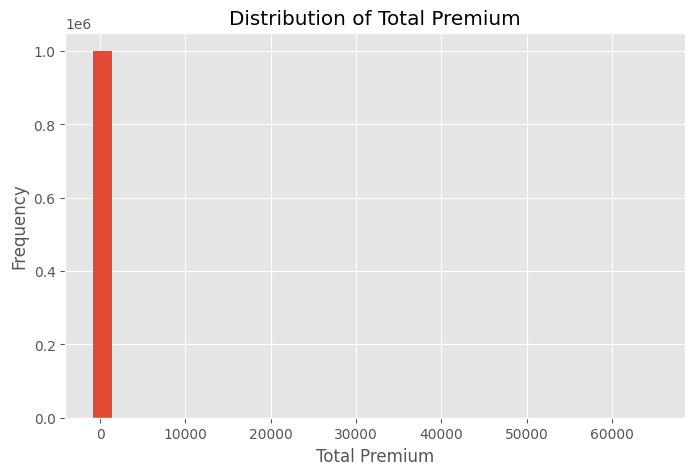

In [ ]:
plt.figure(figsize=(8,5))

df["TotalPremium"].hist(bins=30)

plt.title("Distribution of Total Premium")
plt.xlabel("Total Premium")
plt.ylabel("Frequency")

plt.show()

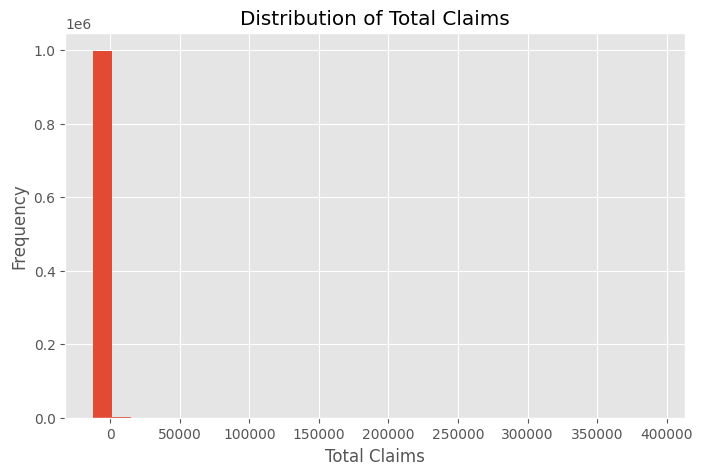

In [ ]:
plt.figure(figsize=(8,5))

df["TotalClaims"].hist(bins=30)

plt.title("Distribution of Total Claims")
plt.xlabel("Total Claims")
plt.ylabel("Frequency")

plt.show()

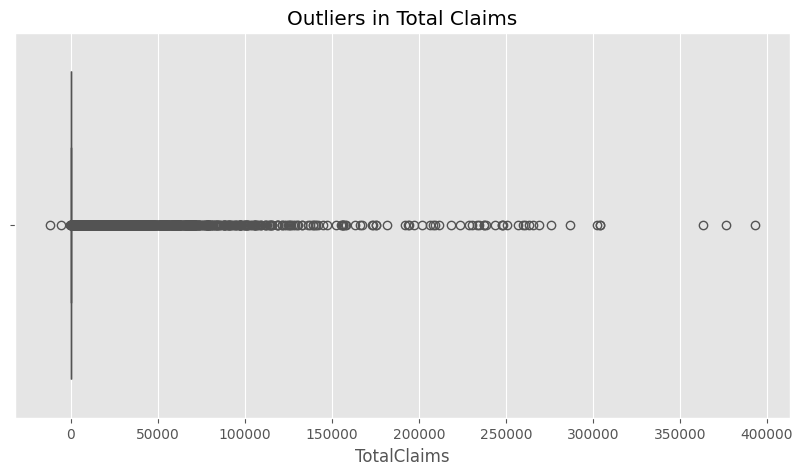

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["TotalClaims"])

plt.title("Outliers in Total Claims")

plt.show()

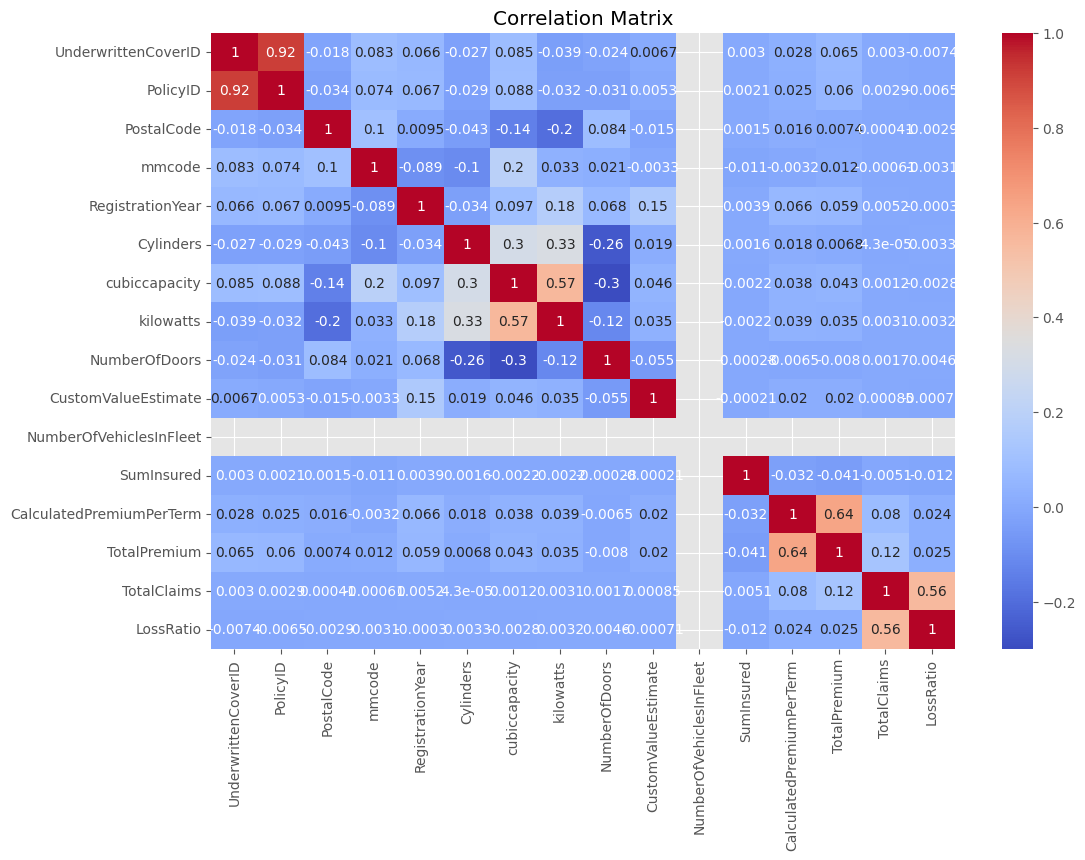

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

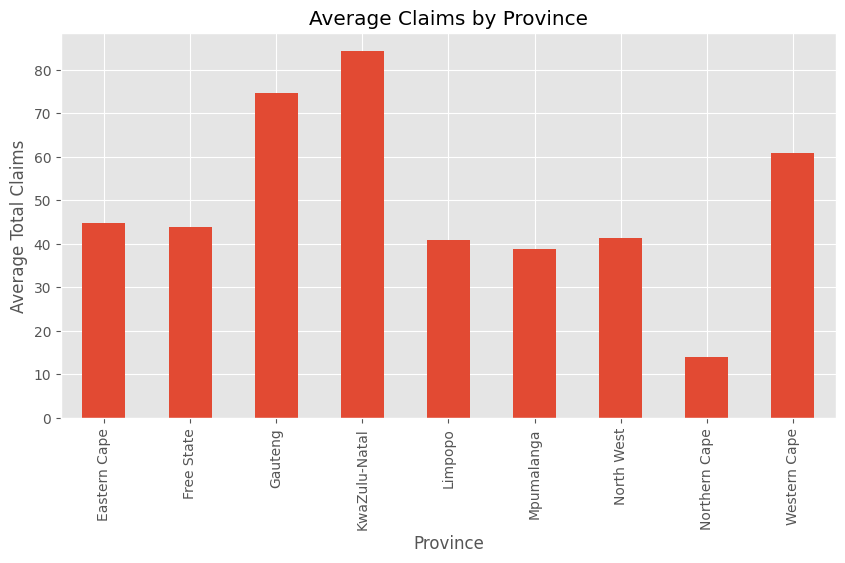

In [14]:
province_mean.plot(kind="bar", figsize=(10,5))

plt.title("Average Claims by Province")

plt.ylabel("Average Total Claims")

plt.show()

In [13]:
province_mean = df.groupby("Province")["TotalClaims"].mean()

province_mean.sort_values(ascending=False)

Province
KwaZulu-Natal    84.234293
Gauteng          74.630009
Western Cape     60.831482
Eastern Cape     44.713432
Free State       43.822975
North West       41.317426
Limpopo          40.927553
Mpumalanga       38.785147
Northern Cape    14.026726
Name: TotalClaims, dtype: float64

In [19]:
stat, p_value = ttest_ind(
    group_a,
    group_b,
    nan_policy='omit'
)

In [20]:
p_value = run_ttest(group_a, group_b)

print("P-value:", p_value)

P-value: 0.05632044649871941


In [22]:
zip_risk_1 = df[df["PostalCode"] == 2000]["TotalClaims"]

zip_risk_2 = df[df["PostalCode"] == 8000]["TotalClaims"]

stat, zip_risk_p = ttest_ind(
    zip_risk_1,
    zip_risk_2,
    nan_policy='omit'
)

print("Zip Risk P-value:", zip_risk_p)

Zip Risk P-value: 0.0006252010270582995


In [23]:
results = pd.DataFrame({

    "Hypothesis": [
        "Province Risk Difference",
        "Gender Risk Difference",
        "Zip Code Risk Difference",
        "Zip Code Margin Difference"
    ],

    "Test Used": [
        "T-Test",
        "T-Test",
        "T-Test",
        "T-Test"
    ],

    "P-Value": [
        p_value,
        gender_p,
        zip_risk_p,
        zip_p
    ],

    "Decision": [
        "Fail to Reject H0" if p_value > 0.05 else "Reject H0",
        "Fail to Reject H0" if gender_p > 0.05 else "Reject H0",
        "Fail to Reject H0" if zip_risk_p > 0.05 else "Reject H0",
        "Fail to Reject H0" if zip_p > 0.05 else "Reject H0"
    ]
})

results

,Hypothesis,Test Used,P-Value,Decision
0,Province Risk Difference,T-Test,0.056320,Fail to Reject H0
1,Gender Risk Difference,T-Test,0.804107,Fail to Reject H0
2,Zip Code Risk Difference,T-Test,0.000625,Reject H0
3,Zip Code Margin Difference,T-Test,0.712325,Fail to Reject H0
